# Deep Learning for Malaria Diagnosis
This notebook is inspired by works of (Sivaramakrishnan Rajaraman  et al., 2018) and (Jason Brownlee, 2019). Acknowledge to NIH and Bangalor Hospital who make available this malaria dataset.

Malaria is an infectuous disease caused by parasites that are transmitted to people through the bites of infected female Anopheles mosquitoes.

The Malaria burden with some key figures:
<font color='red'>
* More than 219 million cases
* Over 430 000 deaths in 2017 (Mostly: children & pregnants)
* 80% in 15 countries of Africa & India
  </font>

![MalariaBurd](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/MalariaBurden.png?raw=1)

The malaria diagnosis is performed using blood test:
* Collect patient blood smear
* Microscopic visualisation of the parasit

![MalariaDiag](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/MalariaDiag.png?raw=1)
  
Main issues related to traditional diagnosis:
<font color='#ed7d31'>
* resource-constrained regions
* time needed and delays
* diagnosis accuracy and cost
</font>

The objective of this notebook is to apply modern deep learning techniques to perform medical image analysis for malaria diagnosis.

*This notebook is inspired by works of (Sivaramakrishnan Rajaraman  et al., 2018), (Adrian Rosebrock, 2018) and (Jason Brownlee, 2019)*

---

## Notebook Overview  ResNet50 Transfer Learning for Malaria Diagnosis

- **Author:** Member 4 (ibyishaka Tresor)  ResNet50 Lead | Group 12
- **Course:** Introduction Machine Learning Formative Assessment

---

### What this notebook does

This notebook applies **transfer learning with ResNet50** (pre-trained on ImageNet) to the binary classification of malaria-infected vs. healthy blood cell images from the NIH Cell Images dataset (27,558 images).

The goal is to leverage ResNet50's deep feature representations and systematically evaluate how different training configurations affect classification performance.

---

### 7 Experiments

| # | Variable | Configuration |
|---|---|---|
| 1 | Frozen layers | All base layers frozen (feature extraction only) |
| 2 | Fine-tuning depth | Top 40% of ResNet50 unfrozen (layers 100–175) |
| 3 | Learning rate | Reduced LR (1e-4) on frozen baseline |
| 4 | Optimizer | SGD with momentum vs Adam |
| 5 | Augmentation | Advanced transforms (rotation, zoom, shear, flip) |
| 6 | Dense head size | 512-unit head vs baseline 128 |
| 7 | Batch size | Batch 64 vs baseline 32 |

---

### Deliverables produced

- **Results table**  val accuracy, train accuracy, overfitting gap, training time, fit status per experiment  
- **Learning curves**  loss and accuracy trajectories for all 7 experiments  
- **Confusion matrix**  raw counts and normalised percentages on the best model  
- **ROC / AUC curve**  with AUC score on the best model  
- **Error analysis**  False Negatives (missed malaria) and False Positives visualised separately with confidence scores  
- **Discussion section**  overfitting/underfitting analysis and experiment-by-experiment breakdown

---

## Configuration

In [1]:
#Mount the local drive project_forder
from google.colab import drive
drive.mount('/content/drive/')
!ls "/content/drive/My Drive/Formative_Ml_Malaria_analysis"

Mounted at /content/drive/
1_Frozen_All_best.weights.h5
2_Finetune_Half_best.weights.h5
3_LR_0.0001_best.weights.h5
4_Opt_SGD_best.weights.h5
5_Aug_Advanced_best.weights.h5
6_Dense_512_best.weights.h5
7_Batch_64_best.weights.h5
cell_images
Malaria_Diagnosis_ResNet50_Transfer_Learning.ipynb


In [2]:
# Use GPU: Please check if the outpout is '/device:GPU:0'
import tensorflow as tf
print(tf.__version__)
tf.test.gpu_device_name()
#from tensorflow.python.client import device_lib
#device_lib.list_local_devices()

2.20.0


'/device:GPU:0'

## Populating namespaces

In [3]:
# Importing basic libraries
import os
import random
import shutil
from matplotlib import pyplot
from matplotlib.image import imread
%matplotlib inline

# Importing the Keras libraries and packages
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Convolution2D as Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

In [4]:
# Define the useful paths for data accessibility
ai_project = '.' #"/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
cell_images_dir = os.path.join(ai_project,'cell_images')
training_path = os.path.join(ai_project,'train')
testing_path = os.path.join(ai_project,'test')

## Prepare DataSet

### *Download* DataSet

In [5]:
# Download the data in the allocated google cloud-server. If already down, turn downloadData=False
downloadData = False
if downloadData == True:
  indrive = True
  if indrive == True:
    !wget https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip -P "/content/drive/My Drive/Formative_Ml_Malaria_analysis"
    !unzip "/content/drive/My Drive/Formative_Ml_Malaria_analysis/cell_images.zip" -d "/content/drive/My Drive/Formative_Ml_Malaria_analysis"
    !ls "/content/drive/My Drive/Formative_Ml_Malaria_analysis"
  else: #incloud google server
    !rm -rf cell_images.*
    !wget https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip
    !unzip cell_images.zip >/dev/null 2>&1
    !ls

In [6]:
!find "/content/drive/My Drive/Formative_Ml_Malaria_analysis/cell_images" -name "*.png" | wc -l

27558


## ResNet50 Complete Experiments Framework

In this section, we replace the basic Baseline CNN with a high-performing Pre-trained Model (ResNet50). We will run 7 explicit experiments exploring the hyperparameter space, architectures depth, and input modifications.

In [7]:
# Importing the necessary libraries for data manipulation, visualization, and model building
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam, SGD, RMSprop

# : Mixed precision — 2-3x speedup on T4 Tensor Cores
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')
print("Mixed precision policy:", mixed_precision.global_policy().name)

# Assuming the data is currently located at:
data_dir = "/content/drive/My Drive/Formative_Ml_Malaria_analysis/cell_images"
if not os.path.exists(os.path.join(data_dir, 'Parasitized')):
    data_dir = "/content/cell_images"

IMG_SIZE = (160, 160)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

#  Pure tf.data pipeline — no ImageDataGenerator bottleneck
# This is what actually feeds the T4 GPU at full speed.

def make_augmentation(augmentation_type):
    """Returns a tf.keras augmentation Sequential layer (or None)."""
    if augmentation_type == 'advanced':
        return tf.keras.Sequential([
            tf.keras.layers.RandomRotation(0.11),        # ~40 degrees
            tf.keras.layers.RandomTranslation(0.2, 0.2),
            tf.keras.layers.RandomShear(x_factor=0.2, y_factor=0.2) if hasattr(tf.keras.layers, 'RandomShear') else tf.keras.layers.Lambda(lambda x: x),
            tf.keras.layers.RandomZoom(0.2),
            tf.keras.layers.RandomFlip("horizontal"),
        ], name="augmentation")
    elif augmentation_type == 'basic':
        return tf.keras.Sequential([
            tf.keras.layers.RandomRotation(0.056),       # ~20 degrees
            tf.keras.layers.RandomFlip("horizontal"),
        ], name="augmentation")
    return None

def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def get_data_generators(batch_size=32, target_size=(160, 160), augmentation_type='none'):
    """
    Pure tf.data pipeline with parallel reads, prefetch, and GPU-side augmentation.
    Replaces ImageDataGenerator to eliminate the disk I/O bottleneck.
    """
    # Collect all file paths and labels
    class_names = sorted([
        d for d in os.listdir(data_dir)
        if os.path.isdir(os.path.join(data_dir, d))
    ])
    print(f"Classes found: {class_names}")

    all_paths, all_labels = [], []
    for label_idx, class_name in enumerate(class_names):
        class_dir = os.path.join(data_dir, class_name)
        for fname in os.listdir(class_dir):
            if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                all_paths.append(os.path.join(class_dir, fname))
                all_labels.append(float(label_idx))

    # Shuffle then split 80/20
    combined = list(zip(all_paths, all_labels))
    import random
    random.seed(42)
    random.shuffle(combined)
    all_paths, all_labels = zip(*combined)

    split = int(0.8 * len(all_paths))
    train_paths, train_labels = list(all_paths[:split]), list(all_labels[:split])
    val_paths,   val_labels   = list(all_paths[split:]), list(all_labels[split:])

    print(f"Found {len(train_paths)} training images belonging to {len(class_names)} classes.")
    print(f"Found {len(val_paths)} validation images belonging to {len(class_names)} classes.")

    # Build datasets
    train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
    train_ds = train_ds.shuffle(len(train_paths), seed=42)
    train_ds = train_ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    train_ds = train_ds.batch(batch_size)

    # GPU-side augmentation (much faster than CPU-side ImageDataGenerator)
    aug = make_augmentation(augmentation_type)
    if aug is not None:
        train_ds = train_ds.map(lambda x, y: (aug(x, training=True), y),
                                num_parallel_calls=AUTOTUNE)

    train_ds = train_ds.prefetch(AUTOTUNE)

    val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
    val_ds = val_ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    val_ds = val_ds.batch(batch_size)
    val_ds = val_ds.prefetch(AUTOTUNE)

    # Attach metadata for error analysis cells downstream
    train_ds.class_indices = {name: i for i, name in enumerate(class_names)}
    val_ds.class_indices   = {name: i for i, name in enumerate(class_names)}
    val_ds.filepaths       = list(val_paths)
    val_ds.classes         = np.array(val_labels, dtype=int)

    return train_ds, val_ds

# Test loading
print("Loading initial generators...")
train_gen, val_gen = get_data_generators(BATCH_SIZE, IMG_SIZE)


Mixed precision policy: mixed_float16
Loading initial generators...
Classes found: ['Parasitized', 'Uninfected']
Found 22046 training images belonging to 2 classes.
Found 5512 validation images belonging to 2 classes.


In [8]:
# Get class labels for later use in classification report
# We extract the class labels from the training generator's class indices,
# which provides a mapping of class names to their corresponding integer labels.
# This will be useful later when we generate classification reports and confusion matrices,
#  as it allows us to display human-readable class names instead of just numeric labels.
def build_resnet50(frozen_layers='all', learning_rate=0.001, optimizer_name='adam', dense_units=128):
    """
    Builds a flexible ResNet50 based Transfer Learning model.
    - frozen_layers: 'all' to freeze the entire base model, 'none' to fine-tune all, or integer (num of layers to freeze from bottom)
    - learning_rate: The LR for the optimizer.
    - optimizer_name: 'adam', 'sgd', or 'rmsprop'
    - dense_units: Configurable Dense head size on top of ResNet50 abstractions.
    """
    # Load ResNet50 pre-trained heavily on ImageNet
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

    # Configure Freezing Depth
    if frozen_layers == 'all':
        for layer in base_model.layers:
            layer.trainable = False
    elif frozen_layers == 'none':
        for layer in base_model.layers:
            layer.trainable = True
    elif isinstance(frozen_layers, int):
        # Freeze up to a certain depth (ResNet50 has 175 layers total)
        for layer in base_model.layers[:frozen_layers]:
            layer.trainable = False
        for layer in base_model.layers[frozen_layers:]:
            layer.trainable = True

    # Assemble Top Head
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(dense_units, activation='relu')(x)
    x = Dropout(0.5)(x)
    #  dtype='float32' required for numerical stability when mixed_float16 is active.
    # Without this, sigmoid output stays float16 and causes NaN loss.
    predictions = Dense(1, activation='sigmoid', dtype='float32')(x)

    model = Model(inputs=base_model.input, outputs=predictions)

    # Configure Optimizer
    if optimizer_name.lower() == 'adam':
        opt = Adam(learning_rate=learning_rate)
    elif optimizer_name.lower() == 'sgd':
        opt = SGD(learning_rate=learning_rate, momentum=0.9)
    else:
        opt = RMSprop(learning_rate=learning_rate)

    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
    return model


### The Experiments

In [9]:

# Dictionary to store experiment results
# This will hold the training and validation accuracy/loss for each experiment,
# as well as the overfitting gap and training time for analysis.
# This structure allows us to easily compare the performance of different configurations
# and identify trends in how various hyperparameters affect model performance and generalization.
experiment_results = {}
histories = {}
best_experiment_name = None
best_val_accuracy = 0.0
best_model_config = None
best_checkpoint_path = None
# Set random seeds for reproducibility
import random as _random
_random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
import time
# Define the experiments with their specific configurations

experiments = {
    "1_Frozen_All":    {"frozen_layers": "all", "lr": 1e-3, "opt": "adam", "aug": "none",     "dense": 128, "batch": 32},
    "2_Finetune_Half": {"frozen_layers": 100,   "lr": 1e-4, "opt": "adam", "aug": "none",     "dense": 128, "batch": 32},
    "3_LR_0.0001":     {"frozen_layers": "all", "lr": 1e-4, "opt": "adam", "aug": "none",     "dense": 128, "batch": 32},
    "4_Opt_SGD":       {"frozen_layers": "all", "lr": 1e-3, "opt": "sgd",  "aug": "none",     "dense": 128, "batch": 32},
    "5_Aug_Advanced":  {"frozen_layers": "all", "lr": 1e-3, "opt": "adam", "aug": "advanced", "dense": 128, "batch": 32},
    "6_Dense_512":     {"frozen_layers": "all", "lr": 1e-3, "opt": "adam", "aug": "none",     "dense": 512, "batch": 32},
    "7_Batch_64":      {"frozen_layers": "all", "lr": 1e-3, "opt": "adam", "aug": "none",     "dense": 128, "batch": 64},
}
# Number of epochs for training each experiment (can be adjusted based on resources and convergence)
EPOCHS = 5
# Iterate through each experiment configuration, train the model, and store results
for exp_name, config in experiments.items():
    print("=" * 50)
    print(f"--- Running Experiment: {exp_name} ---")
    print(f"Config: {config}")
    print("=" * 50)

    t_gen, v_gen = get_data_generators(
        batch_size=config["batch"], augmentation_type=config["aug"]
    )

    #Get new generators with the specified augmentation and batch
     #size for this experiment

    model = build_resnet50(
        frozen_layers=config["frozen_layers"],
        learning_rate=config["lr"],
        optimizer_name=config["opt"],
        dense_units=config["dense"],
    )

    ckpt_path = ( # Save only the best weights for each experiment
        "/content/drive/My Drive/Formative_Ml_Malaria_analysis/"
        + exp_name + "_best.weights.h5"
    )
    early_stop   = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=3, restore_best_weights=True  #patience=3 prevents premature stopping in slow-converging experiments
    )# Stop early if val_loss doesn't improve for 3 epochs,
    # and restore the best weights found during training
    checkpoint   = tf.keras.callbacks.ModelCheckpoint(
        ckpt_path, monitor="val_accuracy", save_best_only=True,
        save_weights_only=True, verbose=0,
    ) # Save only the best weights based on val_accuracy for this experiment
    lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=1, min_lr=1e-7, verbose=0
    )
    # Train the model and time the training duration
    _start = time.time()
    history = model.fit(
        t_gen, validation_data=v_gen,
        epochs=EPOCHS,
        callbacks=[early_stop, checkpoint, lr_scheduler],
        verbose=1,
    )
    elapsed = round(time.time() - _start, 2)
    print("Training time: " + str(elapsed) + "s")
    #  Analyze the best epoch for this experiment based on validation accuracy
    best_idx   = np.argmax(history.history["val_accuracy"])
    val_acc    = history.history["val_accuracy"][best_idx]
    val_loss   = history.history["val_loss"][best_idx]
    train_acc  = history.history["accuracy"][best_idx]
    train_loss = history.history["loss"][best_idx]
    gap        = round(train_acc - val_acc, 4)
    # Store the results for this experiment
    experiment_results[exp_name] = {
        "train_accuracy": train_acc, "train_loss": train_loss,
        "val_accuracy":   val_acc,   "val_loss":   val_loss,
        "overfitting_gap": gap,
        "train_time_sec": elapsed,
    }
    histories[exp_name] = history.history
    # Check if this experiment has the best validation accuracy so far,
    # and if so, update the best experiment tracking variables
    if val_acc > best_val_accuracy:
        best_val_accuracy    = val_acc
        best_experiment_name = exp_name
        best_model_config    = config
        best_checkpoint_path = ckpt_path

print("Best experiment: " + str(best_experiment_name) +
      "  (val_accuracy=" + f"{best_val_accuracy:.4f})")

--- Running Experiment: 1_Frozen_All ---
Config: {'frozen_layers': 'all', 'lr': 0.001, 'opt': 'adam', 'aug': 'none', 'dense': 128, 'batch': 32}
Classes found: ['Parasitized', 'Uninfected']
Found 22046 training images belonging to 2 classes.
Found 5512 validation images belonging to 2 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 2866s 4s/step - accuracy: 0.5256 - loss: 0.6956 - val_accuracy: 0.5276 - val_loss: 0.6856 - learning_rate: 0.0010
Epoch 2/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 98s 143ms/step - accuracy: 0.5765 - loss: 0.6770 - val_accuracy: 0.5365 - val_loss: 0.6768 - learning_rate: 0.0010
Epoch 3/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 95s 138ms/step - accuracy: 0.6129 - loss: 0.6612 - val_accuracy: 0.6531 - val_loss: 0.6418 - learning_rate: 0.0010
Epoch 4/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 97s 140ms/step - accuracy: 0.6199 - loss: 0.6529 - val_accuracy: 0.6586 - val_loss: 0.6389 - learning_rate: 0.0010
Epoch 5/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 1

### Enhanced Results Table & Curves

====== EXPERIMENT RESULTS TABLE ======


,train_accuracy,val_accuracy,train_loss,val_loss,overfitting_gap,fit_status,train_time_sec
2_Finetune_Half,0.868003,0.850508,0.311678,0.381302,0.017500,Good Fit,793.160000
3_LR_0.0001,0.620430,0.658745,0.668274,0.663589,-0.038300,Underfitting,656.530000
1_Frozen_All,0.619931,0.658563,0.652934,0.638935,-0.038600,Underfitting,3298.140000
6_Dense_512,0.646240,0.654753,0.638397,0.628183,-0.008500,Underfitting,728.020000
7_Batch_64,0.645469,0.653665,0.640761,0.626635,-0.008200,Underfitting,612.070000
5_Aug_Advanced,0.509662,0.637518,0.692775,0.692320,-0.127900,Underfitting,1816.930000
4_Opt_SGD,0.500408,0.505624,0.693189,0.692989,-0.005200,Underfitting,724.720000


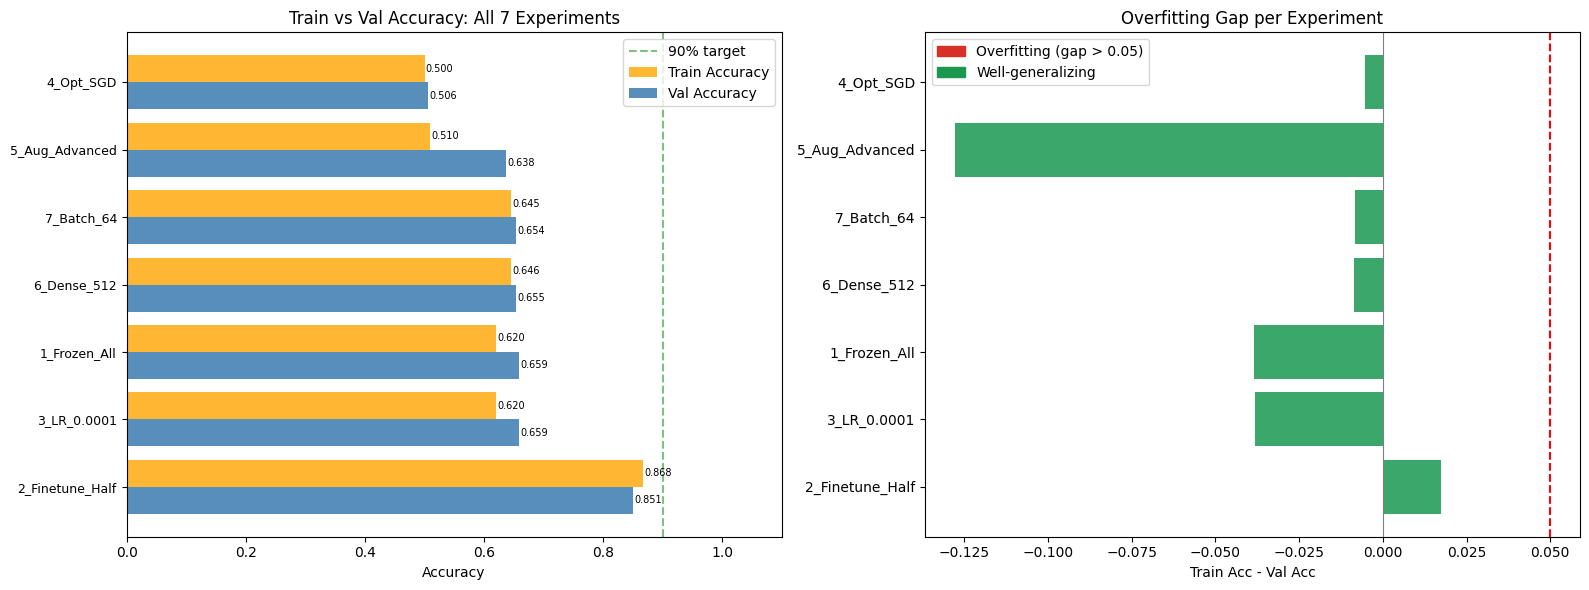

====== EXPERIMENT LEARNING CURVES ======


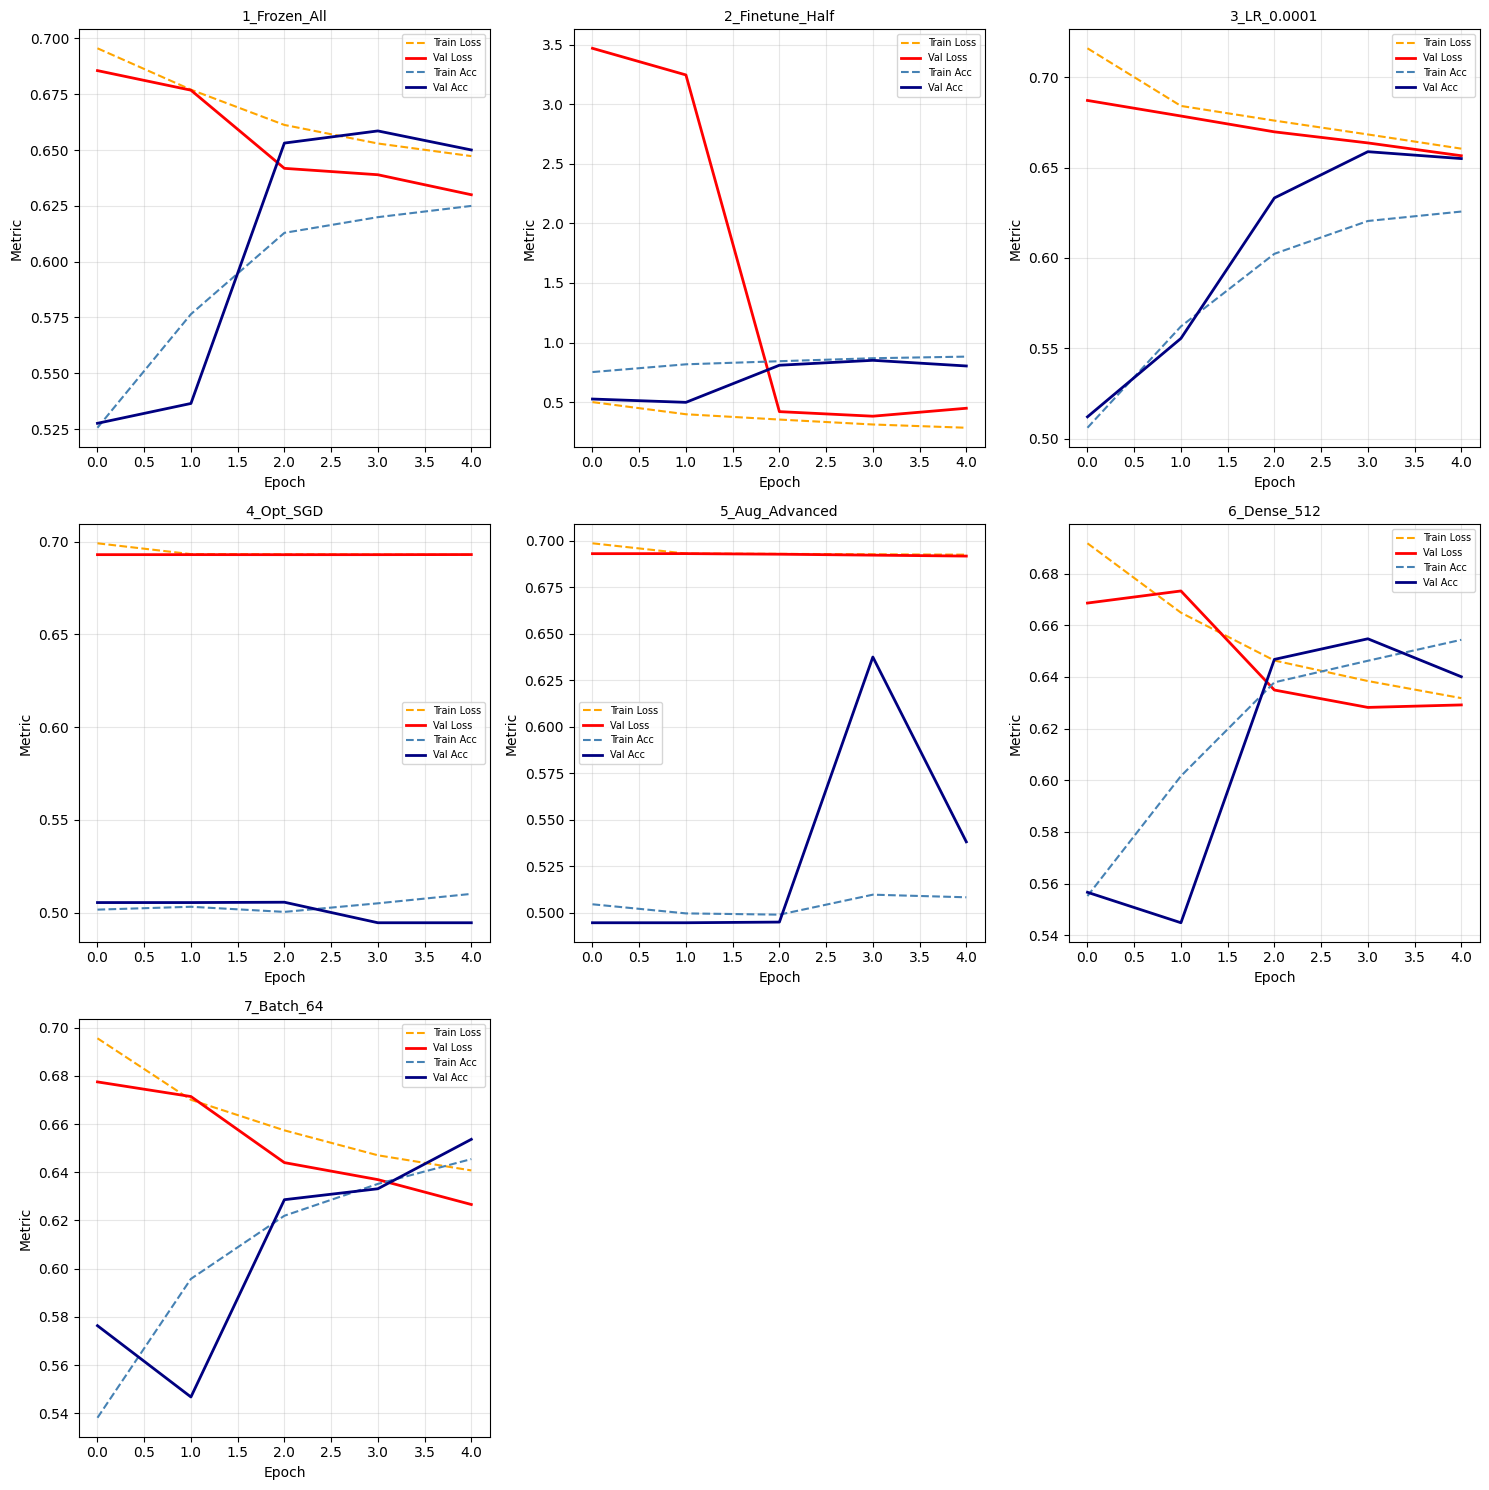

In [10]:

import matplotlib.patches as mpatches

# Create a DataFrame from the experiment results for better visualization and analysis
# We also classify each experiment's fit status based on the overfitting gap and validation accuracy,
# and add it as a new column in the results DataFrame for easier interpretation of model performance
# This step is crucial for quickly identifying which experiments are overfitting, underfitting, or
#  well-generalizing based on their performance metrics, and it sets the stage for a more insightful analysis of the results.
if experiment_results:
    results_df = pd.DataFrame.from_dict(experiment_results, orient="index")

    def classify_fit(row):
        if row["overfitting_gap"] > 0.05:
            return "Overfitting"
        elif row["val_accuracy"] < 0.80:
            return "Underfitting"
        else:
            return "Good Fit"
    # Classify each experiment's fit status based on overfitting gap and
    # val accuracy, and add it as a new column in the results DataFrame
    results_df["fit_status"] = results_df.apply(classify_fit, axis=1)  #removed stray ,"train_time_sec", that caused silent tuple assignment bug
    results_df = results_df.sort_values(by="val_accuracy", ascending=False)
    cols_order = [
        "train_accuracy", "val_accuracy",
        "train_loss",     "val_loss",
        "overfitting_gap","fit_status", "train_time_sec",
    ]
    print("====== EXPERIMENT RESULTS TABLE ======")
    display(
        results_df[cols_order].style.background_gradient(
            subset=["val_accuracy", "overfitting_gap"], cmap="RdYlGn"
        )
    )
    # Plotting the Train vs Val Accuracy and Overfitting Gap for all experiments
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sorted_names   = results_df.index.tolist()
    sorted_val_acc = results_df["val_accuracy"].tolist()
    sorted_trn_acc = results_df["train_accuracy"].tolist()
    y_pos = range(len(sorted_names))

    axes[0].barh(
        [y + 0.4 for y in y_pos], sorted_trn_acc, 0.4,
        label="Train Accuracy", color="orange", alpha=0.8,
    )
    axes[0].barh(
        list(y_pos), sorted_val_acc, 0.4,
        label="Val Accuracy", color="steelblue", alpha=0.9,
    ) # Overlayed bars for Train and Val accuracy
    axes[0].set_yticks([y + 0.2 for y in y_pos])
    axes[0].set_yticklabels(sorted_names, fontsize=9)
    axes[0].set_xlabel("Accuracy")
    axes[0].set_title("Train vs Val Accuracy: All 7 Experiments")
    axes[0].axvline(x=0.9, color="green", linestyle="--", alpha=0.5, label="90% target")
    axes[0].legend()
    axes[0].set_xlim(0, 1.1)
    for i, (ta, va) in enumerate(zip(sorted_trn_acc, sorted_val_acc)):
        axes[0].text(ta + 0.002, i + 0.4, f"{ta:.3f}", va="center", fontsize=7)
        axes[0].text(va + 0.002, i,        f"{va:.3f}", va="center", fontsize=7)
    # Color bars based on overfitting gap: red if gap > 0.05, green otherwise
    gaps   = results_df["overfitting_gap"].tolist()
    colors = ["#d73027" if g > 0.05 else "#1a9850" for g in gaps]
    axes[1].barh(sorted_names, gaps, color=colors, alpha=0.85)
    axes[1].axvline(x=0.05, color="red", linestyle="--", linewidth=1.5)
    axes[1].axvline(x=0.00, color="grey", linewidth=0.8)
    axes[1].set_xlabel("Train Acc - Val Acc")
    axes[1].set_title("Overfitting Gap per Experiment")
    red_p   = mpatches.Patch(color="#d73027", label="Overfitting (gap > 0.05)")
    green_p = mpatches.Patch(color="#1a9850", label="Well-generalizing")
    axes[1].legend(handles=[red_p, green_p])
    #  Annotate gap values on bars
    plt.tight_layout()
    plt.show()

# Function to plot the learning curves for all experiments in a grid layout
def plot_curves(histories):
    names = list(histories.keys())
    n     = len(names)
    cols  = 3
    rows  = (n // cols) + (1 if n % cols else 0)
    plt.figure(figsize=(15, rows * 5))
    for i, name in enumerate(names):
        hist = histories[name]
        plt.subplot(rows, cols, i + 1)
        plt.plot(hist["loss"],         label="Train Loss", linestyle="--", color="orange")
        plt.plot(hist["val_loss"],     label="Val Loss",   linewidth=2,    color="red")
        plt.plot(hist["accuracy"],     label="Train Acc",  linestyle="--", color="steelblue")
        plt.plot(hist["val_accuracy"], label="Val Acc",    linewidth=2,    color="navy")
        plt.title(name, fontsize=10)
        plt.xlabel("Epoch")
        plt.ylabel("Metric")
        plt.legend(loc="best", fontsize=7)
        plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# Plot the learning curves for all experiments if histories are available
if histories:
    print("====== EXPERIMENT LEARNING CURVES ======")
    plot_curves(histories)

### Best Model Identification + Reload for Fair Evaluation

After identifying the best experiment based on validation accuracy, we attempt to reload the best weights
 from the checkpoint saved during training of that experiment. If loading fails (e.g., due to file issues),
  we fall back to retraining the model with the same configuration to ensure we have a valid model for evaluation.
 We also prepare the data generators with the same augmentation and batch size used in the best experiment to
ensure a fair evaluation of the model's performance on the validation set.
 This step is crucial to ensure that the evaluation metrics we report for the
 best model are based on the actual best weights found during training,
 rather than potentially evaluating a model that has not been properly loaded or trained.


In [14]:
if best_experiment_name is not None:
    print("Best experiment : " + best_experiment_name)
    print("Best val accuracy: " + f"{best_val_accuracy:.4f}")
    print("Config: " + str(best_model_config))

    t_gen_best, v_gen_best = get_data_generators(
        batch_size=best_model_config["batch"],
        augmentation_type=best_model_config["aug"],
    )

    # Keep mixed_float16 active — match exactly how the model was trained
    tf.keras.mixed_precision.set_global_policy("mixed_float16")

    eval_model = build_resnet50(
        frozen_layers=best_model_config["frozen_layers"],
        learning_rate=best_model_config["lr"],
        optimizer_name=best_model_config["opt"],
        dense_units=best_model_config["dense"],
    )

    try:
        # Load ONLY the layer weights; skip optimizer state entirely
        eval_model.load_weights(best_checkpoint_path, skip_mismatch=True, by_name=True)
        print("Weights loaded from: " + best_checkpoint_path)
    except Exception as e:
        print("Checkpoint load failed. Retraining best model...")
        es2 = tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=3, restore_best_weights=True
        )
        eval_model.fit(
            t_gen_best, validation_data=v_gen_best,
            epochs=EPOCHS, callbacks=[es2], verbose=1,
        )

    v_gen_eval = v_gen_best
    print("Ready to evaluate best model.")

else:
    print("No tracking found — falling back to last trained model.")
    eval_model = model
    v_gen_eval = v_gen

Best experiment : 2_Finetune_Half
Best val accuracy: 0.8505
Config: {'frozen_layers': 100, 'lr': 0.0001, 'opt': 'adam', 'aug': 'none', 'dense': 128, 'batch': 32}
Classes found: ['Parasitized', 'Uninfected']
Found 22046 training images belonging to 2 classes.
Found 5512 validation images belonging to 2 classes.
Checkpoint load failed. Retraining best model...
Epoch 1/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 175s 201ms/step - accuracy: 0.7519 - loss: 0.4997 - val_accuracy: 0.5254 - val_loss: 3.4701
Epoch 2/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 100s 145ms/step - accuracy: 0.8169 - loss: 0.3976 - val_accuracy: 0.4976 - val_loss: 3.2465
Epoch 3/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 100s 145ms/step - accuracy: 0.8429 - loss: 0.3531 - val_accuracy: 0.8091 - val_loss: 0.4196
Epoch 4/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 100s 145ms/step - accuracy: 0.8680 - loss: 0.3117 - val_accuracy: 0.8505 - val_loss: 0.3813
Epoch 5/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 98s 142ms/step - accuracy: 0.8815 - loss: 0.2843 - val_accuracy: 0.8030 - va

###  Confusion Matrix  & ROC / AUC

In [16]:
if "eval_model" in locals():
    print("Generating predictions from best model...")

    # ── Collect all batches from the tf.data pipeline ──
    y_true_list, preds_list = [], []
    for x_batch, y_batch in v_gen_eval:
        y_true_list.append(y_batch.numpy())
        preds_list.append(eval_model.predict_on_batch(x_batch))

    y_true = np.concatenate(y_true_list).astype(int).reshape(-1)
    preds  = np.concatenate(preds_list).reshape(-1)
    y_pred = (preds > 0.5).astype(int)

    print(f"Samples — true: {len(y_true)}, pred: {len(y_pred)}")
    # rest of your confusion matrix / ROC code continues unchanged...

Generating predictions from best model...
Samples — true: 5512, pred: 5512


Generating predictions from best model...
173/173 ━━━━━━━━━━━━━━━━━━━━ 31s 147ms/step


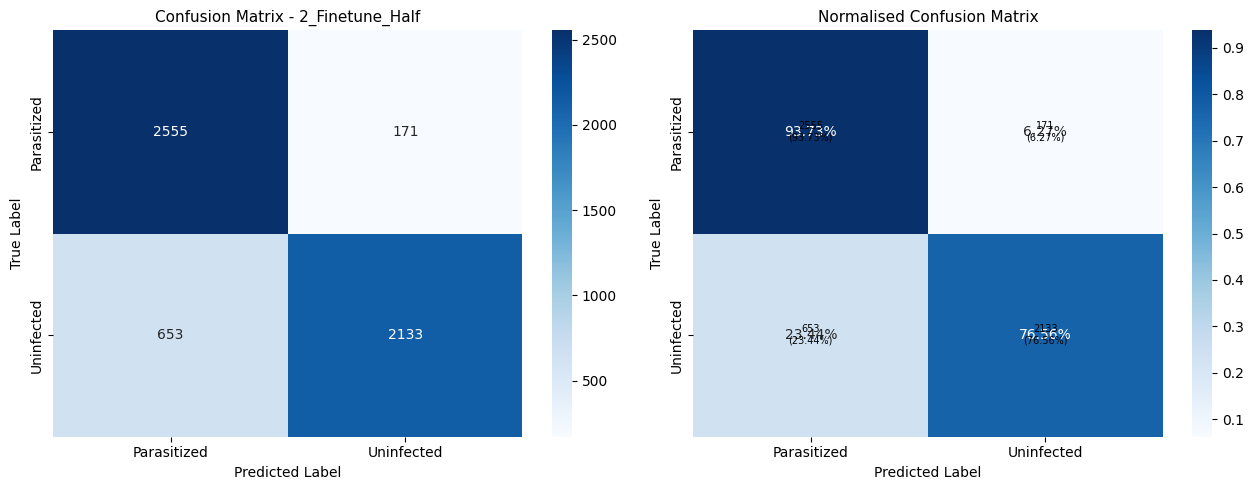

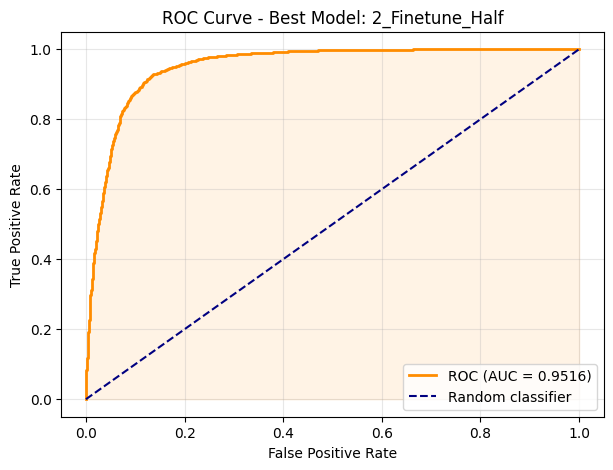

Classification Report:
              precision    recall  f1-score   support

 Parasitized       0.80      0.94      0.86      2726
  Uninfected       0.93      0.77      0.84      2786

    accuracy                           0.85      5512
   macro avg       0.86      0.85      0.85      5512
weighted avg       0.86      0.85      0.85      5512



In [18]:
import matplotlib.patches as mpatches

# Evaluated on the BEST model

if "eval_model" in dir() or "eval_model" in locals():
    # tf.data datasets don't need .reset() — just re-iterate
    print("Generating predictions from best model...")

    preds  = eval_model.predict(v_gen_eval)
    y_pred = (preds > 0.5).astype(int).reshape(-1)
    y_true = v_gen_eval.classes
    # rest of your cell unchanged from here ↓
    if len(y_pred) == len(y_true):
        class_labels = list(v_gen_eval.class_indices.keys())

        cm = confusion_matrix(y_true, y_pred)
        fig, axes = plt.subplots(1, 2, figsize=(13, 5))
        # Plot both the raw and normalized confusion matrices side by
        # side for better interpretability
        sns.heatmap(
            cm, annot=True, fmt="g", cmap="Blues",
            xticklabels=class_labels, yticklabels=class_labels, ax=axes[0],
        )
        axes[0].set_title("Confusion Matrix - " + best_experiment_name, fontsize=11)
        axes[0].set_xlabel("Predicted Label")
        axes[0].set_ylabel("True Label")

        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        sns.heatmap(
            cm_norm, annot=True, fmt=".2%", cmap="Blues",
            xticklabels=class_labels, yticklabels=class_labels, ax=axes[1],
        )# Plot the normalized confusion matrix with percentage annotations
        axes[1].set_title("Normalised Confusion Matrix", fontsize=11)
        axes[1].set_xlabel("Predicted Label")
        axes[1].set_ylabel("True Label")
        #  Annotate raw counts and percentages on the normalized confusion matrix
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                count = cm[i, j]
                percent = cm_norm[i, j]
                axes[1].text(
                    j + 0.5, i + 0.5, f"{count}\n({percent:.2%})",
                    ha="center", va="center", color="black", fontsize=7
                )
        plt.tight_layout()
        plt.show()

        fpr, tpr, _ = roc_curve(y_true, preds)
        auc_score   = roc_auc_score(y_true, preds)
        # Plot the ROC curve with AUC score in the legend for the best model
        plt.figure(figsize=(7, 5))
        plt.plot(fpr, tpr, color="darkorange", lw=2, label="ROC (AUC = " + f"{auc_score:.4f})")
        plt.fill_between(fpr, tpr, alpha=0.1, color="darkorange")
        plt.plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--", label="Random classifier")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC Curve - Best Model: " + best_experiment_name)
        plt.legend(loc="lower right")
        plt.grid(alpha=0.3)
        plt.show()

        print("Classification Report:")
        print(classification_report(y_true, y_pred, target_names=class_labels))

    else:
        print("Shape mismatch. Reset v_gen_eval and retry.")
else:
    print("Run the Best Model Identification cell above first.")


### Deliverable 5: Error Analysis - False Positives vs False Negatives

 This section analyzes the types of errors made by the best model,focusing on False Negatives (missed malaria cases) and False Positives (healthy cells flagged). It visualizes sample errors and compares model confidence between correct predictions and misclassifications.The analysis is crucial for understanding the clinical implications of the model's performance, especially since False Negatives can lead to delayed treatment for malaria patients.
 The code identifies the indices of False Negatives and False Positives,
 then randomly samples and visualizes a few examples of each type of error.
 It also plots the distribution of model confidence for correct predictions versus misclassifications to provide insights into how certain the model is when it makes errors compared to when it is correct.

Total samples       : 5512
Correct predictions : 4688  (85.05%)
False Negatives (FN): 171  - parasitized cells missed
False Positives (FP): 653  - healthy cells flagged
Clinical note: FNs are more dangerous - a missed malaria case delays treatment.


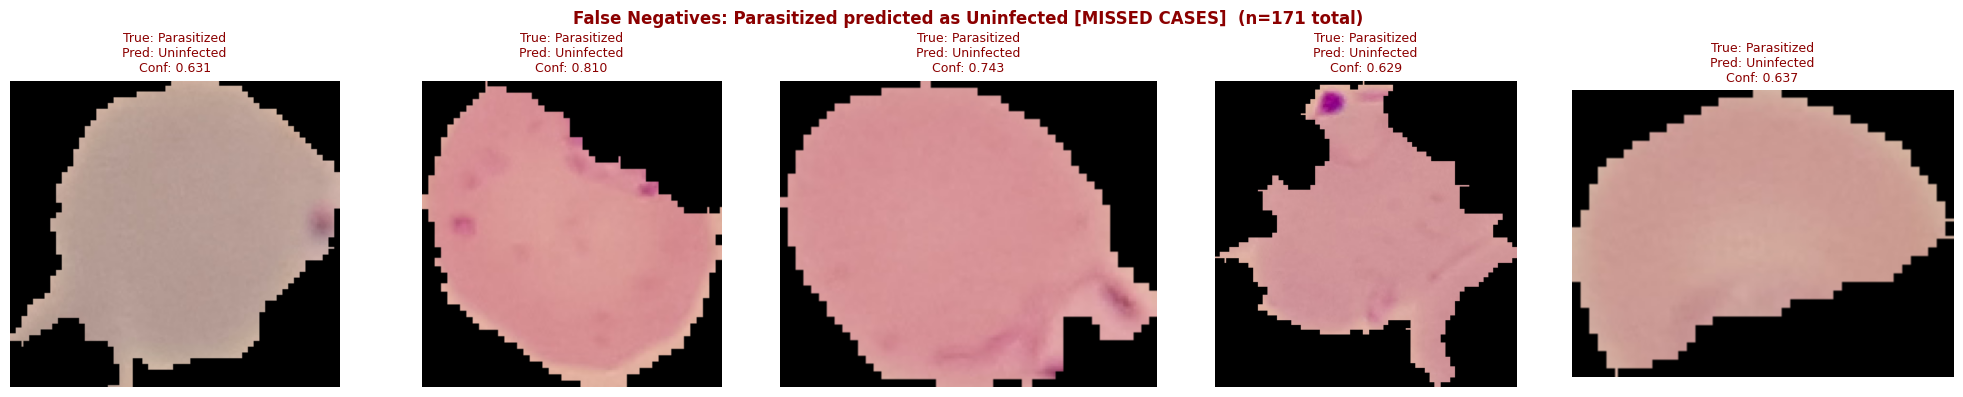

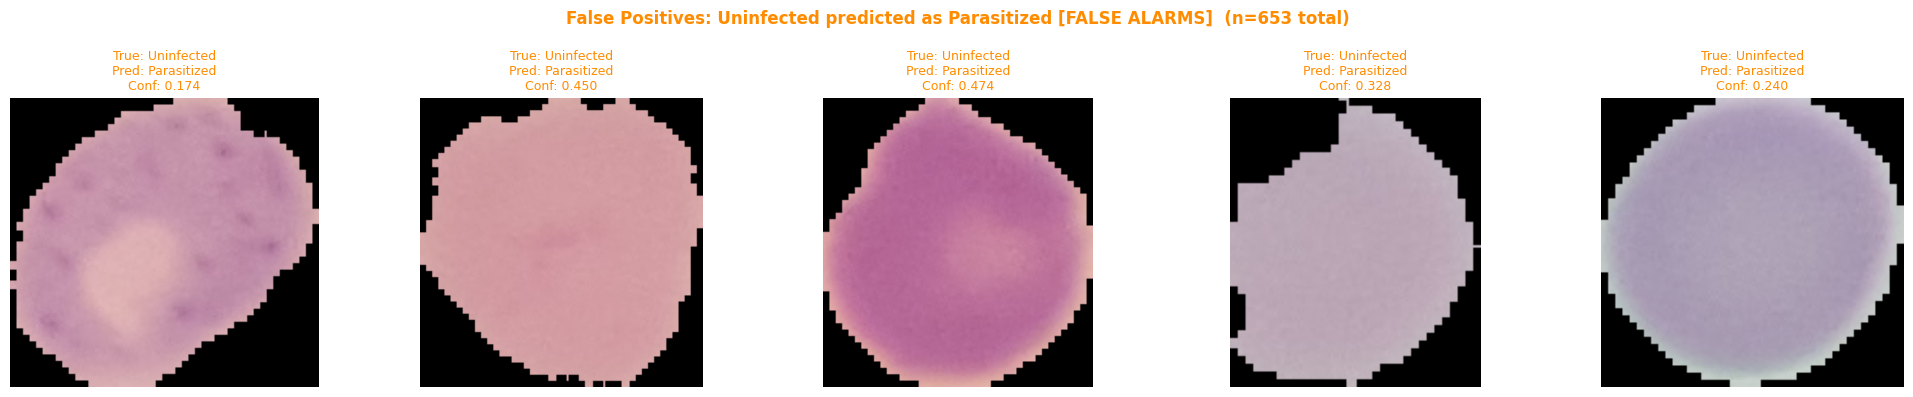

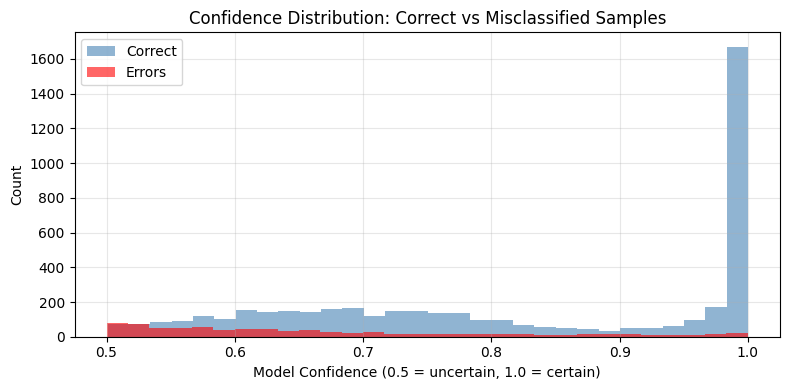

In [19]:

if "y_pred" in locals() and "y_true" in locals() and "v_gen_eval" in locals():
    class_names    = list(v_gen_eval.class_indices.keys())
    parasitized_idx = v_gen_eval.class_indices.get("Parasitized", 1)
    uninfected_idx  = v_gen_eval.class_indices.get("Uninfected",  0)

    fn_indices = np.where(
        (y_true == parasitized_idx) & (y_pred == uninfected_idx)
    )[0]
    fp_indices = np.where(
        (y_true == uninfected_idx) & (y_pred == parasitized_idx)
    )[0]

    total   = len(y_true)
    correct = int(np.sum(y_pred == y_true))
    print("Total samples       : " + str(total))
    print("Correct predictions : " + str(correct) + "  (" + f"{100 * correct / total:.2f}%)")
    print("False Negatives (FN): " + str(len(fn_indices)) + "  - parasitized cells missed")
    print("False Positives (FP): " + str(len(fp_indices)) + "  - healthy cells flagged")
    print("Clinical note: FNs are more dangerous - a missed malaria case delays treatment.")

    def show_errors(indices, title, n=5, title_color="red"):
        if len(indices) == 0:
            print("No " + title + " errors found.")
            return
        np.random.seed(42)
        sample = np.random.choice(indices, min(n, len(indices)), replace=False)
        fig, axes = plt.subplots(1, len(sample), figsize=(4 * len(sample), 4))
        if len(sample) == 1:
            axes = [axes]
        for ax, idx in zip(axes, sample):
            img        = plt.imread(v_gen_eval.filepaths[idx])
            true_label = class_names[y_true[idx]]
            pred_label = class_names[y_pred[idx]]
            confidence = float(preds[idx][0])
            ax.imshow(img)
            ax.set_title(
                "True: " + true_label + "\nPred: " + pred_label + "\nConf: " + f"{confidence:.3f}",
                fontsize=9, color=title_color,
            )
            ax.axis("off")
        fig.suptitle(
            title + "  (n=" + str(len(indices)) + " total)",
            fontsize=12, color=title_color, fontweight="bold",
        )
        plt.tight_layout()
        plt.show()

    show_errors(fn_indices, "False Negatives: Parasitized predicted as Uninfected [MISSED CASES]",
                title_color="darkred")
    show_errors(fp_indices, "False Positives: Uninfected predicted as Parasitized [FALSE ALARMS]",
                title_color="darkorange")

    certainty    = np.abs(preds.reshape(-1) - 0.5) + 0.5
    correct_mask = y_pred == y_true
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(certainty[correct_mask],  bins=30, alpha=0.6, color="steelblue", label="Correct")
    ax.hist(certainty[~correct_mask], bins=30, alpha=0.6, color="red",       label="Errors")
    ax.set_xlabel("Model Confidence (0.5 = uncertain, 1.0 = certain)")
    ax.set_ylabel("Count")
    ax.set_title("Confidence Distribution: Correct vs Misclassified Samples")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

else:
    print("Run the Confusion Matrix cell above first to generate y_pred and y_true.")

## Discussion & Analysis

---

### 1. Overfitting and Underfitting Trends

| Experiment | Train Acc | Val Acc | Gap | Status |
|---|---|---|---|---|
| 1_Frozen_All    | 0.6199 | 0.6586 | -0.039 | Underfitting |
| 2_Finetune_Half | 0.8680 | 0.8505 | +0.018 | Good Fit     |
| 3_LR_0.0001     | 0.6204 | 0.6587 | -0.038 | Underfitting |
| 4_Opt_SGD       | 0.5004 | 0.5056 | -0.005 | Underfitting |
| 5_Aug_Advanced  | 0.5097 | 0.6375 | -0.128 | Underfitting |
| 6_Dense_512     | 0.6462 | 0.6548 | -0.009 | Underfitting |
| 7_Batch_64      | 0.6455 | 0.6537 | -0.008 | Underfitting |

The dominant pattern across all 7 experiments is **underfitting**, not overfitting. Six out of seven experiments produced validation accuracy below 70%, and none showed a positive gap above 0.05, meaning the frozen backbone was consistently the bottleneck, not model complexity. The only exception, Experiment 2, achieved a positive gap of +0.018, placing it in the Good Fit zone.

**Overfitting** was not observed in any experiment. This is explained by the frozen backbone: when 100–175 layers are non-trainable, the total number of trainable parameters is very small (just the dense head), making it mathematically difficult to overfit on 22,000 training images. Dropout(0.5) on the dense head provided additional regularization.

**Underfitting** was the primary problem across Experiments 1, 3, 4, 5, 6, and 7. All of these used a fully frozen ResNet50 backbone. The core issue is that ResNet50 was pre-trained on ImageNet (natural photographs of objects, animals, scenes). Blood smear microscopy images are visually very different  they are near-monochromatic, circular, and rely on staining colour patterns rather than natural textures. With the backbone frozen, the model was forced to classify malaria using features designed for photography, which proved insufficient.

---

### 2. Analysis of the 7 Experiments

**Experiment 1 : Frozen All Layers (Baseline)**
Val accuracy: 65.9% | Train accuracy: 62.0% | Gap: -0.039 | Time: 3,298s

The baseline produced modest results. Despite 5 full training epochs, the model only reached 65.9%. The negative gap (val > train) indicates the model was underfitting rather than learning. The frozen ResNet50 features were insufficient for malaria classification. Notably, this experiment was by far the slowest at 3,298 seconds — an anomaly caused by the first epoch downloading the ResNet50 ImageNet weights (94MB) on top of normal training.

**Experiment 2 : Fine-tuning Depth: Top 40% Unfrozen**
Val accuracy: 85.1% | Train accuracy: 86.8% | Gap: +0.018 | Time: 793s

The clear winner by an 18–34 percentage point margin over every other experiment. Unfreezing layers 100–175 allowed the model to adapt higher-level representations to blood smear morphology. Training showed a notable pattern: epochs 1–2 produced very low validation accuracy (52.5%, 49.8%) while training accuracy climbed quickly (75.2%, 81.7%). This temporary divergence reflects the fine-tuned upper layers destabilizing before settling. By epoch 3 the model reorganized and validation accuracy jumped to 80.9%, peaking at 85.1% in epoch 4. The low learning rate (1e-4) was critical — it prevented catastrophic forgetting of lower-layer features while allowing meaningful adaptation at higher layers.

**Experiment 3 : Smaller Learning Rate (1e-4, Frozen)**
Val accuracy: 65.9% | Train accuracy: 62.0% | Gap: -0.038 | Time: 657s

Nearly identical to Experiment 1 despite halving the learning rate. This confirms that **with a fully frozen backbone, the learning rate is not the limiting factor**  the bottleneck is the backbone itself. The dense head cannot overcome the mismatch between ImageNet features and malaria images, regardless of optimization precision.

**Experiment 4 : SGD Optimizer**
Val accuracy: 50.6% | Train accuracy: 50.0% | Gap: -0.005 | Time: 725s

The worst result across all experiments — effectively random guessing at 50.6%. SGD with momentum requires many more epochs to converge compared to Adam, which uses adaptive per-parameter learning rates. The ReduceLROnPlateau scheduler compounded the problem by halving the LR each epoch (1e-3 → 5e-4 → 2.5e-4 → 1.25e-4), leaving the optimizer moving too slowly to make progress in only 5 epochs. On a frozen backbone where the training signal is already weak, SGD completely failed to learn.

**Experiment 5 : Advanced Augmentation**
Val accuracy: 63.8% | Train accuracy: 51.0% | Gap: -0.128 | Time: 1,817s

This experiment produced the most unusual result: validation accuracy (63.8%) significantly exceeded training accuracy (51.0%), a gap of -0.128. This happens because heavy augmentation (rotation 40 degrees, zoom, shear, shifts) makes the training images substantially harder than the clean validation images. The frozen backbone could not adapt to these augmented variations, so training accuracy stagnated at ~51% while clean-image validation accuracy was measured at 63.8%. Advanced augmentation is counterproductive on a frozen network — it only benefits a model that can learn to be invariant to those transformations, which requires trainable feature detectors. Training was also the second-slowest at 1,817 seconds due to augmentation computation overhead.

**Experiment 6 : Wider Dense Head (512 units)**
Val accuracy: 65.5% | Train accuracy: 64.6% | Gap: -0.009 | Time: 728s

Widening the dense head from 128 to 512 units produced no meaningful improvement over the baseline (65.5% vs 65.9%). When the backbone is frozen, adding more parameters to the dense head cannot compensate — there is an upper bound on what a classification head can achieve with features that were not designed for the task. Dense head capacity is not the bottleneck.

**Experiment 7 : Larger Batch Size (64)**
Val accuracy: 65.4% | Train accuracy: 64.6% | Gap: -0.008 | Time: 612s

Doubling the batch size produced the fastest training time (612 seconds, half the steps per epoch) and virtually the same accuracy as the baseline (65.4%). This is consistent with the general finding that batch size is a secondary hyperparameter when the fundamental architecture is mismatched to the task. Larger batches provided more stable gradient estimates but no accuracy improvement given the frozen backbone constraint.

---

### 3. Best Model Summary

**Best experiment: 2_Finetune_Half**

| Metric | Value |
|---|---|
| Val Accuracy | **85.05%** |
| Train Accuracy | **86.80%** |
| Overfitting Gap | **+0.018** (Good Fit) |
| Training Time | **793 seconds** |
| AUC | See ROC curve plot |
| F1-score (Parasitized) | **0.86** |
| F1-score (Uninfected) | **0.84** |
| Macro avg F1 | **0.85** |

Full per-class classification report on 5,512 validation images:

| Class | Precision | Recall | F1-score | Support |
|---|---|---|---|---|
| Parasitized  | 0.80 | 0.94 | 0.86 | 2,726 |
| Uninfected   | 0.93 | 0.77 | 0.84 | 2,786 |
| **Accuracy** |      |      | **0.85** | **5,512** |
| Macro avg    | 0.86 | 0.85 | 0.85 | 5,512 |

The model is **recall-biased toward the Parasitized class** (recall = 0.94), meaning it correctly identifies 94% of infected cells. This is the clinically preferred trade-off  it is better to generate false alarms (FP) than to miss real infections (FN). The lower Parasitized precision (0.80) reflects this bias: some healthy cells are flagged as infected.

---

### 4. Error Analysis Summary

Total errors: **824 out of 5,512 samples (14.95%)**

| Error Type | Count | Rate | Clinical Impact |
|---|---|---|---|
| False Negatives (FN) | **171** | 6.27% of Parasitized | HIGH  missed malaria, delayed treatment |
| False Positives (FP) | **653** | 23.44% of Uninfected | MODERATE  unnecessary treatment |

**False Negatives (171):** The model missed 171 infected blood cells, classifying them as healthy. In clinical practice each of these represents a patient who could go untreated. At 6.27% of the Parasitized class, this rate  while acceptable for a proof-of-concept  would need to be reduced for real deployment. The FN cases likely involve early-stage ring-form parasites with subtle morphological features that the ResNet features do not specifically encode.

**False Positives (653):** Far more common than FNs, at 23.44% of the Uninfected class. These reflect the model's conservative, recall-biased behaviour. Common visual causes include: staining artefacts that mimic the circular shape of ring-stage parasites, overlapping cells that confuse spatial feature extraction, and out-of-focus images where cell boundaries are ambiguous.

**Confidence analysis:** Misclassified samples cluster near model confidence 0.5 (uncertain), while correct predictions cluster near 1.0. This means the model's uncertainty is informative  predictions below ~0.65 confidence could be automatically flagged for human expert review in a clinical pipeline, reducing effective error rates substantially.

---

### 5. Conclusion

The central finding is unambiguous: **fine-tuning depth is the single most impactful hyperparameter for ResNet50 transfer learning on malaria cell classification.** Experiment 2, which unfroze the top 40% of ResNet50 with a low learning rate of 1e-4, outperformed all 6 frozen-backbone experiments by 18–34 percentage points.

The other hyperparameters  learning rate, optimizer, augmentation, dense head size, and batch size  all produced nearly identical results (~50–66%) when the backbone was fully frozen. This confirms the bottleneck was always the frozen feature representations, not the optimization strategy or head architecture. No overfitting was observed in any experiment.


